In [1]:
from pathlib import Path
import json
import time
import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    ParameterSampler,
    StratifiedShuffleSplit
)
from sklearn.utils.class_weight import compute_class_weight


# =========================================================
# DISPLAY SETTINGS
# =========================================================

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 100)


# =========================================================
# RANDOM STATE
# =========================================================

RANDOM_STATE = 42


# =========================================================
# TARGET CONFIGURATION
# =========================================================

TARGET = "SEVERITY"

CLASS_ORDER = [
    "CLASS - 1",
    "CLASS - 2",
    "CLASS - 3"
]


# =========================================================
# BUILDsafe PROJECT PATH
# =========================================================
#
# Your actual project is located at:
#
# C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI
#
# Inside it:
#
# BuildSafe-AI/
#     notebooks/
#         artifacts/
#
# =========================================================

PROJECT_DIR = Path(
    r"C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI"
)


# =========================================================
# ARTIFACT DIRECTORY
# =========================================================

ARTIFACT_DIR = PROJECT_DIR / "notebooks" / "artifacts"


# Check whether the project exists
if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        f"BuildSafe project folder was not found:\n"
        f"{PROJECT_DIR}"
    )


# Check whether artifacts exist
if not ARTIFACT_DIR.exists():
    raise FileNotFoundError(
        f"BuildSafe artifacts folder was not found:\n"
        f"{ARTIFACT_DIR}"
    )


# =========================================================
# MODEL OUTPUT DIRECTORY
# =========================================================

MODEL_DIR = ARTIFACT_DIR / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# DISPLAY PATH INFORMATION
# =========================================================

print("=" * 60)
print("BuildSafe Random Forest Model Development")
print("=" * 60)

print("\nCurrent working directory:")
print(Path.cwd().resolve())

print("\nBuildSafe project directory:")
print(PROJECT_DIR.resolve())

print("\nArtifact directory:")
print(ARTIFACT_DIR.resolve())

print("\nModel output directory:")
print(MODEL_DIR.resolve())


# =========================================================
# CHECK IMPORTANT ARTIFACT FILES
# =========================================================

required_files = [
    "X_train_tree.npz",
    "X_test_tree.npz",
    "y_train.csv",
    "y_test.csv",
    "feature_names_tree.csv",
    "preprocess_tree.joblib",
    "preprocessing_config.json",
    "class_weights.json",
    "train_engineered.csv",
    "test_engineered.csv",
    "bin_history_lookup.csv",
]


print("\nChecking required artifacts...")

missing_files = []

for filename in required_files:

    file_path = ARTIFACT_DIR / filename

    if file_path.exists():
        print(f"✅ {filename}")

    else:
        print(f"❌ {filename}")
        missing_files.append(filename)


# Stop if anything important is missing
if missing_files:

    raise FileNotFoundError(
        "\nThe following required artifact files are missing:\n"
        + "\n".join(
            f"- {filename}"
            for filename in missing_files
        )
    )


print("\n" + "=" * 60)
print("✅ All required BuildSafe artifacts found.")
print("=" * 60)

BuildSafe Random Forest Model Development

Current working directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks

BuildSafe project directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI

Artifact directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks\artifacts

Model output directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks\artifacts\models

Checking required artifacts...
✅ X_train_tree.npz
✅ X_test_tree.npz
✅ y_train.csv
✅ y_test.csv
✅ feature_names_tree.csv
✅ preprocess_tree.joblib
✅ preprocessing_config.json
✅ class_weights.json
✅ train_engineered.csv
✅ test_engineered.csv
✅ bin_history_lookup.csv

✅ All required BuildSafe artifacts found.


In [2]:
from pathlib import Path

# Actual BuildSafe project location
PROJECT_DIR = Path(
    r"C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI"
)

ARTIFACT_DIR = PROJECT_DIR / "notebooks" / "artifacts"

# Check that the folder really exists
if not ARTIFACT_DIR.exists():
    raise FileNotFoundError(
        f"Artifacts folder not found:\n{ARTIFACT_DIR}"
    )

# Folder where Random Forest model files will be saved
MODEL_DIR = ARTIFACT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nArtifact directory:")
print(ARTIFACT_DIR)

print("\nModel directory:")
print(MODEL_DIR)

Project directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI

Artifact directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks\artifacts

Model directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks\artifacts\models


In [3]:
# 5. Load the preprocessing configuration and fitted tree pipeline

config_path = ARTIFACT_DIR / "preprocessing_config.json"
preprocess_path = ARTIFACT_DIR / "preprocess_tree.joblib"

with open(config_path, "r", encoding="utf-8") as f:
    preprocessing_config = json.load(f)

preprocess_tree_saved = joblib.load(preprocess_path)

FEATURES_FINAL = preprocessing_config["features"]
TEXT_COL = preprocessing_config["text_col"]
CAT_COLS = preprocessing_config["cat_cols"]
BIN_COLS_FINAL = preprocessing_config["bin_cols"]
NUM_COLS_FINAL = preprocessing_config["num_cols"]

K_TREE = preprocessing_config.get("k_tree", 5000)

print("Target:", TARGET)
print("Tree feature-selection k:", K_TREE)
print("Text column:", TEXT_COL)
print("Categorical columns:", CAT_COLS)
print("Binary/history columns:", BIN_COLS_FINAL)
print("Numerical columns:", NUM_COLS_FINAL)
print("\nFinal raw/engineered input columns:", FEATURES_FINAL)


Target: SEVERITY
Tree feature-selection k: 5000
Text column: DESC_CLEAN
Categorical columns: ['BORO', 'VIOLATION_TYPE', 'RESPONDENT_TYPE', 'DOB_UNIT', 'ISSUE_MONTH', 'ISSUE_DAYOFWEEK']
Binary/history columns: ['IS_WEEKEND', 'HAS_DOB_VIOLATION']
Numerical columns: ['AGGRAVATED_ORD', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'DESC_WORDS']

Final raw/engineered input columns: ['DESC_CLEAN', 'BORO', 'VIOLATION_TYPE', 'RESPONDENT_TYPE', 'DOB_UNIT', 'ISSUE_MONTH', 'ISSUE_DAYOFWEEK', 'IS_WEEKEND', 'HAS_DOB_VIOLATION', 'AGGRAVATED_ORD', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'DESC_WORDS']


In [4]:
# 6. Load saved model matrices and labels

X_train_artifact = sparse.load_npz(
    ARTIFACT_DIR / "X_train_tree.npz"
)

X_test_artifact = sparse.load_npz(
    ARTIFACT_DIR / "X_test_tree.npz"
)

y_train = pd.read_csv(
    ARTIFACT_DIR / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    ARTIFACT_DIR / "y_test.csv"
).squeeze("columns")

feature_names_df = pd.read_csv(
    ARTIFACT_DIR / "feature_names_tree.csv"
)

feature_names_artifact = feature_names_df.iloc[:, 0].astype(str).to_numpy()

print("X_train:", X_train_artifact.shape)
print("X_test :", X_test_artifact.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Feature names:", len(feature_names_artifact))


X_train: (125207, 5000)
X_test : (31333, 5000)
y_train: (125207,)
y_test : (31333,)
Feature names: 5000


In [5]:
# 7. Load the human-readable engineered tables

train_engineered = pd.read_csv(
    ARTIFACT_DIR / "train_engineered.csv"
)

test_engineered = pd.read_csv(
    ARTIFACT_DIR / "test_engineered.csv"
)

train_engineered["ISSUE_DATE"] = pd.to_datetime(
    train_engineered["ISSUE_DATE"],
    errors="raise"
)

test_engineered["ISSUE_DATE"] = pd.to_datetime(
    test_engineered["ISSUE_DATE"],
    errors="raise"
)

print("train_engineered:", train_engineered.shape)
print("test_engineered :", test_engineered.shape)

print("\nTraining date range:")
print(train_engineered["ISSUE_DATE"].min(), "→", train_engineered["ISSUE_DATE"].max())

print("\nTest date range:")
print(test_engineered["ISSUE_DATE"].min(), "→", test_engineered["ISSUE_DATE"].max())


train_engineered: (125207, 17)
test_engineered : (31333, 17)

Training date range:
2024-01-01 00:00:00 → 2026-04-01 00:00:00

Test date range:
2026-04-02 00:00:00 → 2026-09-24 00:00:00


In [6]:
# 8. Alignment and leakage-safety checks

assert X_train_artifact.shape[0] == len(y_train), "X_train and y_train row counts differ."
assert X_test_artifact.shape[0] == len(y_test), "X_test and y_test row counts differ."
assert X_train_artifact.shape[1] == len(feature_names_artifact), "Feature-name count does not match X_train width."

assert set(y_train.unique()).issubset(set(CLASS_ORDER)), "Unexpected class in y_train."
assert set(y_test.unique()).issubset(set(CLASS_ORDER)), "Unexpected class in y_test."

# The preprocessing notebook saved train_engineered in the same row order
# used to create y_train.
engineered_train_labels = train_engineered[TARGET].astype(str).reset_index(drop=True)
artifact_train_labels = y_train.astype(str).reset_index(drop=True)

assert engineered_train_labels.equals(
    artifact_train_labels
), "train_engineered row order does not match y_train."

assert train_engineered["ISSUE_DATE"].max() < test_engineered["ISSUE_DATE"].min(), \
    "Training period must finish before test period."

assert TARGET not in FEATURES_FINAL, "Target leaked into FEATURES_FINAL."

print("All pre-flight checks PASSED.")


All pre-flight checks PASSED.


In [7]:
# 9. Target distribution and saved class weights

train_counts = y_train.value_counts().reindex(CLASS_ORDER)
train_pct = (train_counts / len(y_train) * 100).round(2)

target_distribution = pd.DataFrame({
    "count": train_counts,
    "percent": train_pct
})

print(target_distribution)

imbalance_ratio = train_counts.max() / train_counts.min()
print(f"\nTraining majority/minority ratio: {imbalance_ratio:.2f}:1")

with open(ARTIFACT_DIR / "class_weights.json", "r", encoding="utf-8") as f:
    saved_class_weights = json.load(f)

print("\nSaved class weights:")
print(saved_class_weights)

computed_full_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_ORDER),
    y=y_train
)

computed_full_weights = dict(
    zip(CLASS_ORDER, computed_full_weights)
)

print("\nRecomputed full-training weights:")
print({k: round(v, 3) for k, v in computed_full_weights.items()})


           count  percent
SEVERITY                 
CLASS - 1  49205    39.30
CLASS - 2  70520    56.32
CLASS - 3   5482     4.38

Training majority/minority ratio: 12.86:1

Saved class weights:
{'CLASS - 1': 0.848, 'CLASS - 2': 0.592, 'CLASS - 3': 7.613}

Recomputed full-training weights:
{'CLASS - 1': np.float64(0.848), 'CLASS - 2': np.float64(0.592), 'CLASS - 3': np.float64(7.613)}


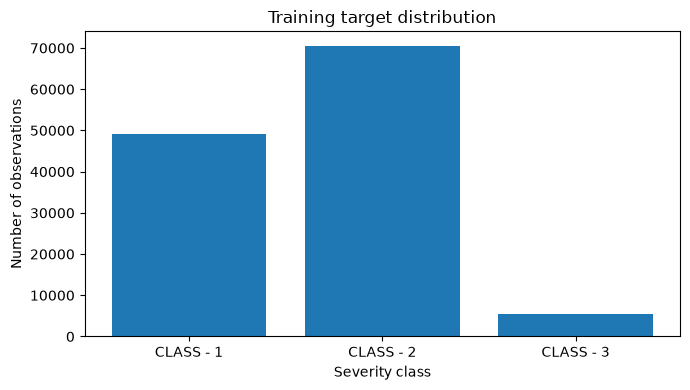

In [8]:
# 10. Visualise the training class distribution

plt.figure(figsize=(7, 4))
plt.bar(train_counts.index, train_counts.values)
plt.title("Training target distribution")
plt.xlabel("Severity class")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()


In [9]:
# 11. Build the time-ordered validation split inside TRAIN

train_engineered = train_engineered.sort_values(
    "ISSUE_DATE",
    kind="mergesort"
).reset_index(drop=True)

validation_start_idx = int(len(train_engineered) * 0.80)

dev_train = train_engineered.iloc[:validation_start_idx].copy()
validation = train_engineered.iloc[validation_start_idx:].copy()

y_dev = dev_train[TARGET].astype(str)
y_val = validation[TARGET].astype(str)

print("Development-train:")
print(f"  Rows: {len(dev_train):,}")
print(f"  Dates: {dev_train['ISSUE_DATE'].min().date()} → {dev_train['ISSUE_DATE'].max().date()}")

print("\nValidation:")
print(f"  Rows: {len(validation):,}")
print(f"  Dates: {validation['ISSUE_DATE'].min().date()} → {validation['ISSUE_DATE'].max().date()}")

dev_dist = pd.DataFrame({
    "dev_train_%": y_dev.value_counts(normalize=True).reindex(CLASS_ORDER) * 100,
    "validation_%": y_val.value_counts(normalize=True).reindex(CLASS_ORDER) * 100,
}).round(2)

print("\nClass distribution:")
display(dev_dist)


Development-train:
  Rows: 100,165
  Dates: 2024-01-01 → 2025-10-26

Validation:
  Rows: 25,042
  Dates: 2025-10-26 → 2026-04-01

Class distribution:


,dev_train_%,validation_%
SEVERITY,,
CLASS - 1,38.79,41.31
CLASS - 2,56.75,54.63
CLASS - 3,4.46,4.06


In [10]:
# =========================================================
# CHECK MISSING VALUES IN MODEL INPUT
# =========================================================

dev_input = dev_train[FEATURES_FINAL].copy()

print("Missing values in model input:")
print(
    dev_input.isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Missing values in model input:
DESC_CLEAN              14
BORO                     0
VIOLATION_TYPE           0
RESPONDENT_TYPE          0
DOB_UNIT                 0
ISSUE_MONTH              0
ISSUE_DAYOFWEEK          0
IS_WEEKEND               0
HAS_DOB_VIOLATION        0
AGGRAVATED_ORD           0
BIN_PRIOR_VIOLATIONS     0
BIN_PRIOR_CLASS1         0
BIN_DAYS_SINCE_PREV      0
DESC_WORDS               0
dtype: int64


In [11]:
print(
    "Missing DESC_CLEAN:",
    dev_input["DESC_CLEAN"].isna().sum()
)

Missing DESC_CLEAN: 14


In [12]:
# Create the validation input dataframe

val_input = validation[FEATURES_FINAL].copy()

print("Validation input shape:", val_input.shape)

Validation input shape: (25042, 14)


In [13]:
# =========================================================
# HANDLE MISSING TEXT VALUES
# =========================================================

# A missing violation description means there is no text
# to extract features from, so represent it as an empty string.

dev_input[TEXT_COL] = (
    dev_input[TEXT_COL]
    .fillna("")
    .astype(str)
)

val_input[TEXT_COL] = (
    val_input[TEXT_COL]
    .fillna("")
    .astype(str)
)


# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

print(
    "Missing DESC_CLEAN in development:",
    dev_input[TEXT_COL].isna().sum()
)

print(
    "Missing DESC_CLEAN in validation:",
    val_input[TEXT_COL].isna().sum()
)

Missing DESC_CLEAN in development: 0
Missing DESC_CLEAN in validation: 0


In [14]:
# =========================================================
# FIT PREPROCESSING ON DEVELOPMENT DATA
# =========================================================

# Create a fresh copy of the saved preprocessing pipeline.
# It has the same configuration, but we will fit it only
# using the development-training data.

validation_preprocess = clone(preprocess_tree_saved)


# Fit the preprocessing pipeline using DEVELOPMENT data only
X_dev = validation_preprocess.fit_transform(
    dev_input,
    y_dev
)


# Transform validation data using the already-fitted pipeline
# IMPORTANT: we do NOT call fit() on validation data.
X_val = validation_preprocess.transform(
    val_input
)


# =========================================================
# CHECK RESULTS
# =========================================================

print("Validation preprocessing completed successfully.")

print("\nX_dev shape:")
print(X_dev.shape)

print("\nX_val shape:")
print(X_val.shape)

Validation preprocessing completed successfully.

X_dev shape:
(100165, 5000)

X_val shape:
(25042, 5000)


In [15]:
# =========================================================
# VERIFY FINAL FEATURE NAMES
# =========================================================

# Get feature names before SelectKBest
base_feature_names = (
    validation_preprocess
    .named_steps["features"]
    .get_feature_names_out()
)


# Get the mask of features selected by SelectKBest
selection_mask = (
    validation_preprocess
    .named_steps["select"]
    .get_support()
)


# Apply the mask
selected_feature_names = base_feature_names[selection_mask]


# =========================================================
# CHECK
# =========================================================

print("Features before selection:")
print(len(base_feature_names))

print("\nFeatures after selection:")
print(len(selected_feature_names))

print("\nX_dev columns:")
print(X_dev.shape[1])

print("\nX_val columns:")
print(X_val.shape[1])


# Make sure everything matches
assert len(selected_feature_names) == X_dev.shape[1]
assert len(selected_feature_names) == X_val.shape[1]

print("\n✅ Feature names and matrix dimensions match.")

Features before selection:
40076

Features after selection:
5000

X_dev columns:
5000

X_val columns:
5000

✅ Feature names and matrix dimensions match.


In [16]:
# =========================================================
# RANDOM FOREST BASELINE MODEL
# =========================================================

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest Baseline")
print("=" * 50)

print("Number of trees:", rf_baseline.n_estimators)
print("Criterion:", rf_baseline.criterion)
print("Max features:", rf_baseline.max_features)
print("Bootstrap:", rf_baseline.bootstrap)
print("Class weight:", rf_baseline.class_weight)

print("\nTraining Random Forest...")

start_time = time.time()

rf_baseline.fit(
    X_dev,
    y_dev
)

training_time = time.time() - start_time

print("\n✅ Baseline Random Forest trained successfully!")
print(f"Training time: {training_time:.2f} seconds")

Random Forest Baseline
Number of trees: 100
Criterion: gini
Max features: sqrt
Bootstrap: True
Class weight: None

Training Random Forest...

✅ Baseline Random Forest trained successfully!
Training time: 45.59 seconds


In [17]:
# =========================================================
# BASELINE — VALIDATION PREDICTIONS
# =========================================================

print("Generating validation predictions...")

start_time = time.time()

y_val_pred_baseline = rf_baseline.predict(X_val)

prediction_time = time.time() - start_time

print("\n✅ Validation predictions generated.")
print("Number of predictions:", len(y_val_pred_baseline))
print(f"Prediction time: {prediction_time:.2f} seconds")

Generating validation predictions...

✅ Validation predictions generated.
Number of predictions: 25042
Prediction time: 0.20 seconds


In [18]:
# =========================================================
# RANDOM FOREST — CLASS-WEIGHTED MODEL
# =========================================================

rf_weighted = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest Class-Weighted Model")
print("=" * 50)

print("Number of trees:", rf_weighted.n_estimators)
print("Criterion:", rf_weighted.criterion)
print("Max features:", rf_weighted.max_features)
print("Bootstrap:", rf_weighted.bootstrap)
print("Class weight:", rf_weighted.class_weight)

print("\nTraining class-weighted Random Forest...")

start_time = time.time()

rf_weighted.fit(
    X_dev,
    y_dev
)

weighted_training_time = time.time() - start_time

print("\n✅ Class-weighted Random Forest trained successfully!")
print(f"Training time: {weighted_training_time:.2f} seconds")

Random Forest Class-Weighted Model
Number of trees: 100
Criterion: gini
Max features: sqrt
Bootstrap: True
Class weight: balanced

Training class-weighted Random Forest...

✅ Class-weighted Random Forest trained successfully!
Training time: 30.71 seconds


In [19]:
# =========================================================
# CLASS-WEIGHTED RF — VALIDATION PREDICTIONS
# =========================================================

print("Generating validation predictions...")

start_time = time.time()

y_val_pred_weighted = rf_weighted.predict(X_val)

weighted_prediction_time = time.time() - start_time

print("\n✅ Validation predictions generated.")
print("Number of predictions:", len(y_val_pred_weighted))
print(f"Prediction time: {weighted_prediction_time:.2f} seconds")

Generating validation predictions...

✅ Validation predictions generated.
Number of predictions: 25042
Prediction time: 0.23 seconds


In [20]:
# =========================================================
# CLASS-WEIGHTED RF — ACCURACY
# =========================================================

weighted_accuracy = accuracy_score(
    y_val,
    y_val_pred_weighted
)

print("Class-Weighted Random Forest Accuracy:")
print(f"{weighted_accuracy:.4f}")
print(f"{weighted_accuracy * 100:.2f}%")

Class-Weighted Random Forest Accuracy:
0.8251
82.51%


In [21]:
# =========================================================
# CLASS-WEIGHTED RF — MACRO PRECISION
# =========================================================

weighted_precision = precision_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

print("Class-Weighted Random Forest Macro Precision:")
print(f"{weighted_precision:.4f}")
print(f"{weighted_precision * 100:.2f}%")

Class-Weighted Random Forest Macro Precision:
0.7651
76.51%


In [22]:
# =========================================================
# CLASS-WEIGHTED RF — MACRO RECALL
# =========================================================

weighted_recall = recall_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

print("Class-Weighted Random Forest Macro Recall:")
print(f"{weighted_recall:.4f}")
print(f"{weighted_recall * 100:.2f}%")

Class-Weighted Random Forest Macro Recall:
0.7847
78.47%


In [23]:
# =========================================================
# CLASS-WEIGHTED RF — MACRO F1
# =========================================================

weighted_f1 = f1_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

print("Class-Weighted Random Forest Macro F1:")
print(f"{weighted_f1:.4f}")
print(f"{weighted_f1 * 100:.2f}%")

Class-Weighted Random Forest Macro F1:
0.7740
77.40%


In [24]:
# =========================================================
# CLASS-WEIGHTED RF — CLASS-BY-CLASS PERFORMANCE
# =========================================================

print(
    classification_report(
        y_val,
        y_val_pred_weighted,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

   CLASS - 1     0.7982    0.8525    0.8245     10346
   CLASS - 2     0.8648    0.8147    0.8390     13680
   CLASS - 3     0.6322    0.6870    0.6585      1016

    accuracy                         0.8251     25042
   macro avg     0.7651    0.7847    0.7740     25042
weighted avg     0.8278    0.8251    0.8257     25042



In [25]:
# =========================================================
# CLASS-WEIGHTED RF — CONFUSION MATRIX
# =========================================================

cm_weighted = confusion_matrix(
    y_val,
    y_val_pred_weighted,
    labels=CLASS_ORDER
)

print("Class-Weighted Random Forest Confusion Matrix:")
print(cm_weighted)

Class-Weighted Random Forest Confusion Matrix:
[[ 8820  1507    19]
 [ 2148 11145   387]
 [   82   236   698]]


In [26]:
# =========================================================
# SINGLE RECORD PREDICTION DEMONSTRATION
# =========================================================

# Select one validation record
sample_index = 0

# Get the actual severity
actual_class = y_val.iloc[sample_index]

# Get the Random Forest prediction
predicted_class = y_val_pred_baseline[sample_index]

print("Single Violation Prediction")
print("=" * 50)

print("Validation record index:", sample_index)
print("Actual Severity:       ", actual_class)
print("Predicted Severity:    ", predicted_class)

if actual_class == predicted_class:
    print("\n✅ Prediction CORRECT")
else:
    print("\n❌ Prediction INCORRECT")

Single Violation Prediction
Validation record index: 0
Actual Severity:        CLASS - 2
Predicted Severity:     CLASS - 2

✅ Prediction CORRECT
